In [1]:
import sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt
import scienceplots
import zbi

os.chdir(os.path.join(os.getcwd(), ".."))
from cmb.simulators import PlanckLiteSimulatorR1

plt.style.use(['science','notebook'])
%matplotlib inline


In [2]:
run_dir = "runs/planck_lite_r2"
chain_dir = "chains/pliklite_r2"
CHECKPOINT_LIST = [
    "round_00000_200000_mlpv2_r1.pt",
    "round_00000_200000_mlpv2_r2.pt",
    "round_00000_200000_mlpv2_r3.pt",
    "round_00000_200000_mlpv2_r4.pt",
    "round_00000_200000_mlpv2_r5.pt",
    "round_00000_200000_mlpv2_r6.pt",
    "round_00000_200000_mlpv2_r7.pt",
    "round_00000_200000_mlpv2_r8.pt",
    "round_00000_200000_mlpv2_r9.pt",
    "round_00000_200000_mlpv2_r10.pt",
]

samples_list = []
for checkpoint in CHECKPOINT_LIST:
    samples = zbi.sample_model(
        run_dir=run_dir, 
        checkpoint=checkpoint, 
        n_samples=1_000,
    )
    samples_list.append(samples)


In [3]:
from getdist import loadMCSamples

def load_chain(chain_dir: str) -> np.ndarray:
    s = loadMCSamples(os.path.join(chain_dir, "chain"))
    s.removeBurn(0)
    s.removeBurnFraction(0.3)
    names = list(s.getParamNames().list())
    by_name = {n: i for i, n in enumerate(names)}

    ombh2 = s.samples[:, by_name["ombh2"]]
    omch2 = s.samples[:, by_name["omch2"]]
    tau = s.samples[:, by_name["tau"]]
    logA = s.samples[:, by_name["logA"]]
    ns = s.samples[:, by_name["ns"]]
    theta_MC_100 = s.samples[:, by_name["theta_MC_100"]]

    return np.column_stack([ombh2, omch2, theta_MC_100, tau, logA, ns])

chain_samples = load_chain(chain_dir)


Removed no burn in
Removed no burn in


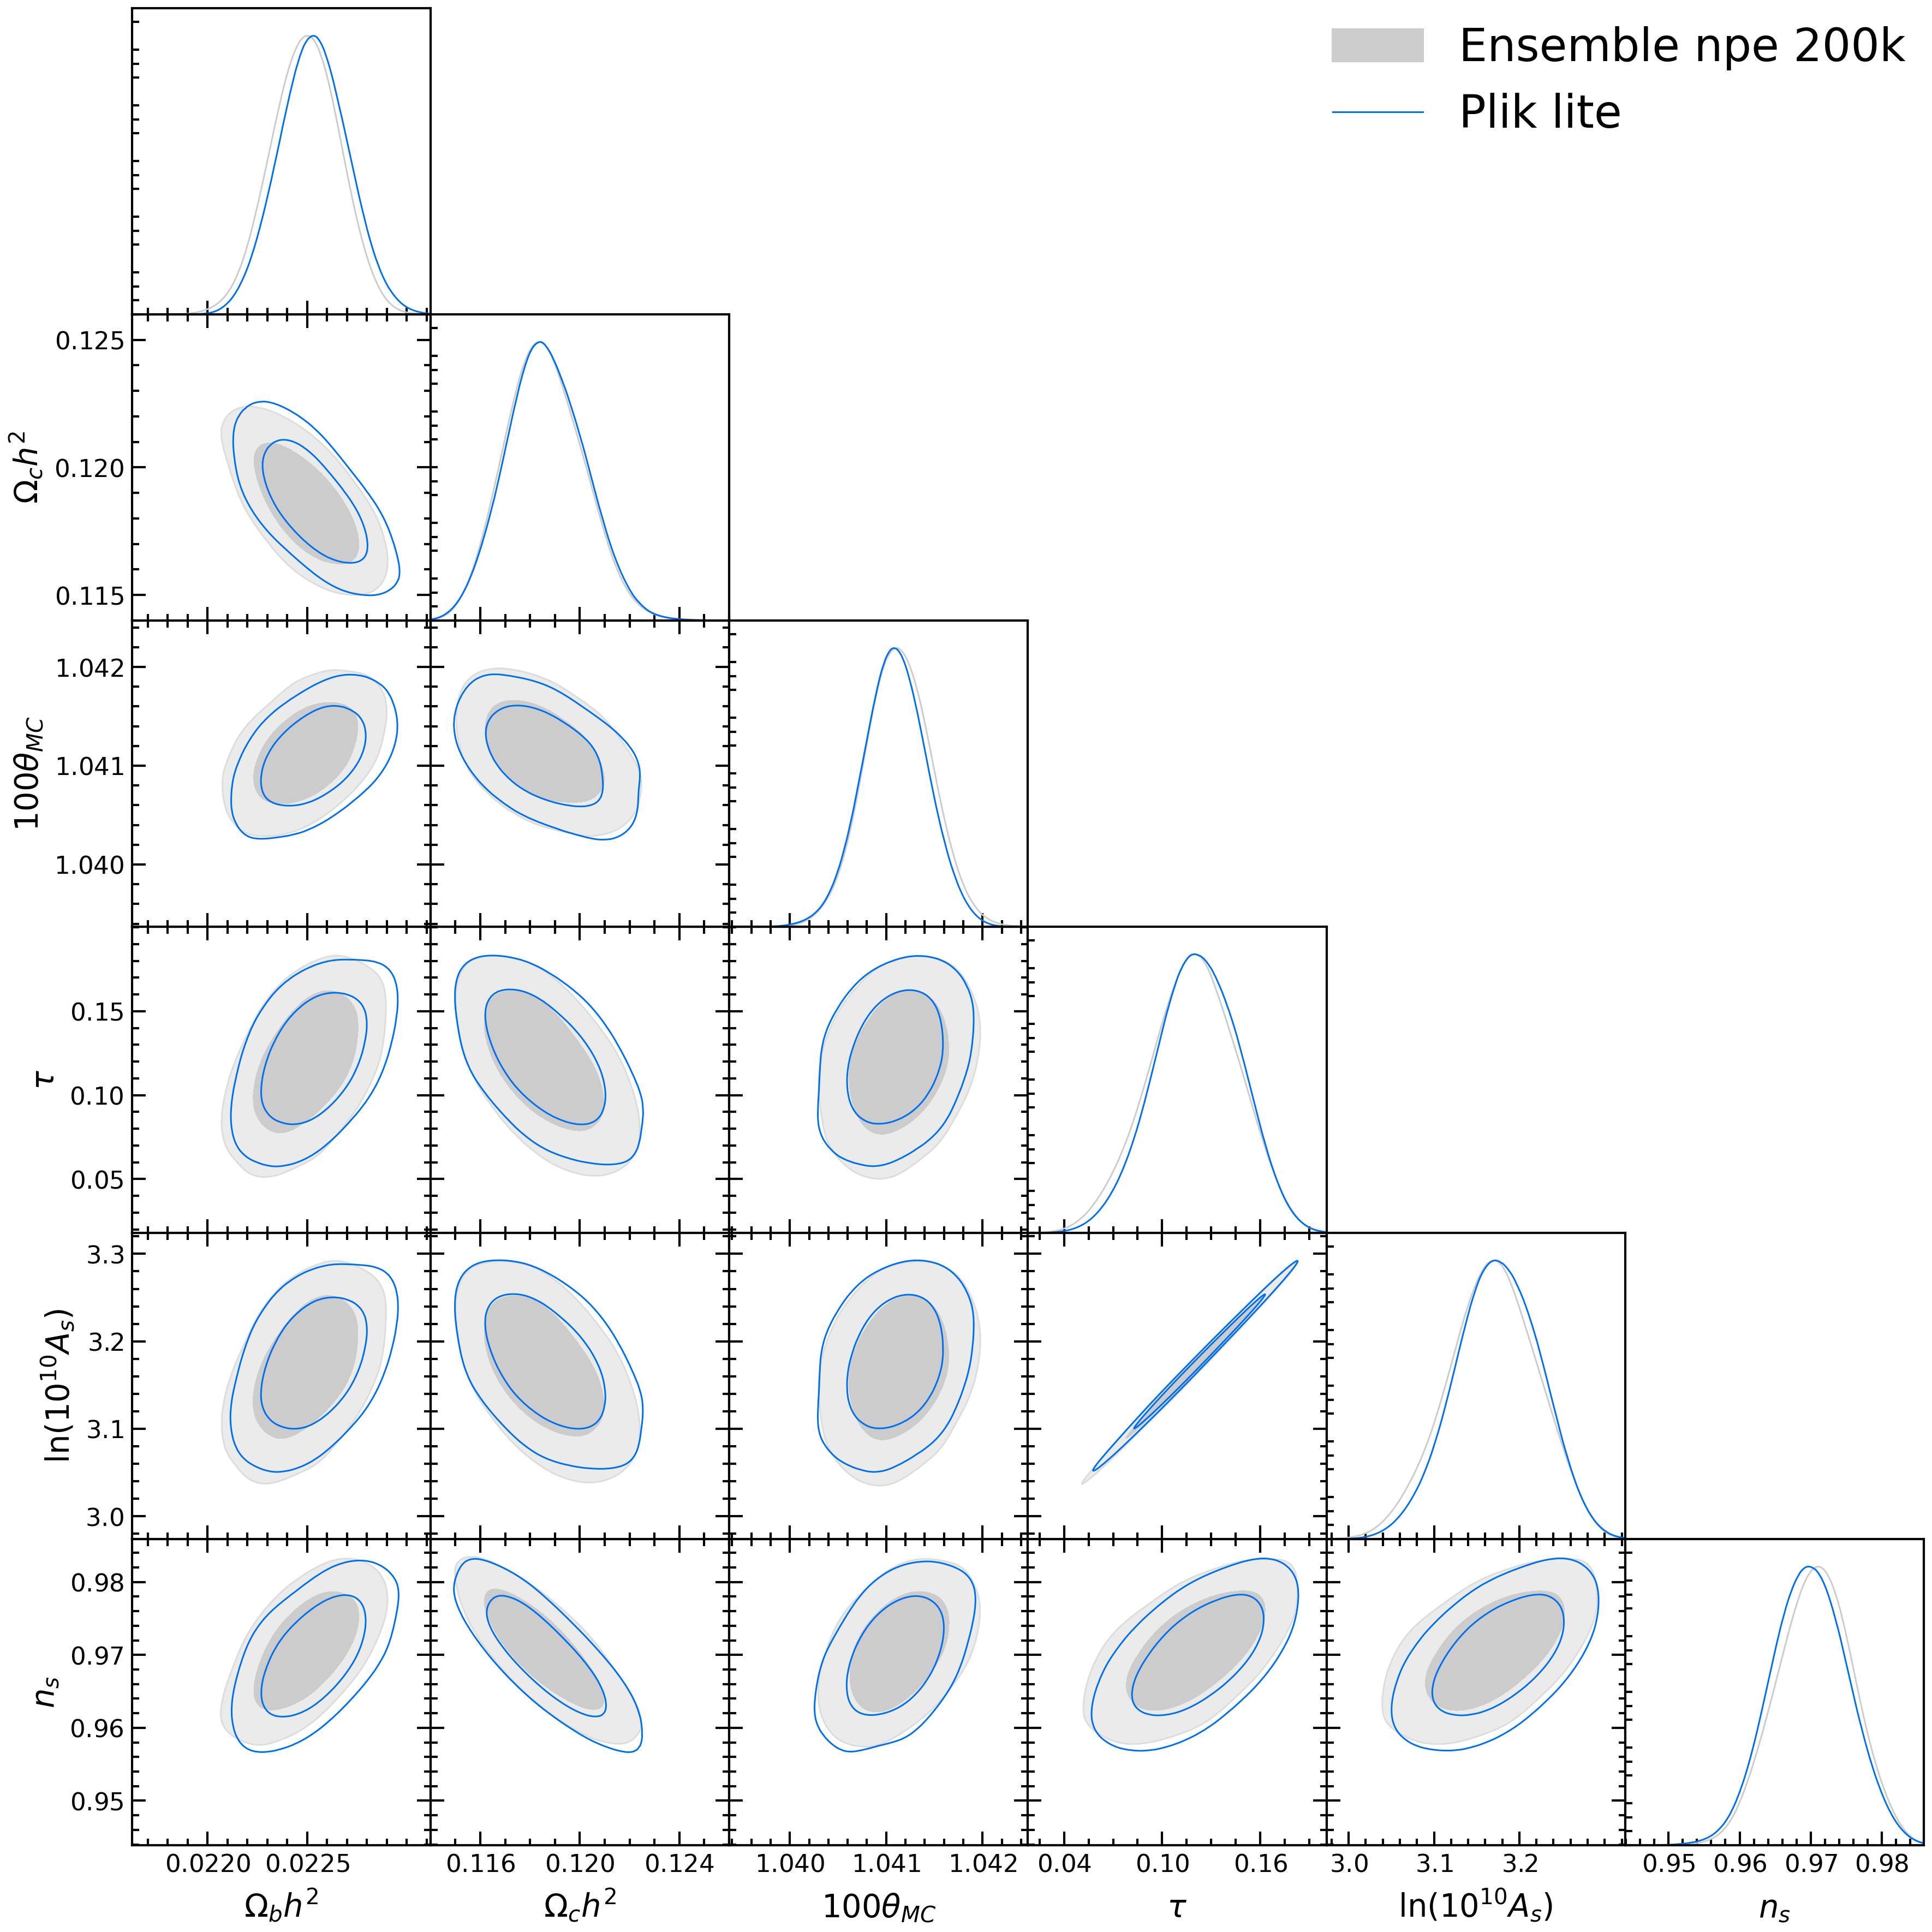

In [4]:
from zbi.utils.plotting import plot_ppc

samples_ensemble = np.concatenate([
    samples for samples in samples_list
])

g = plot_ppc(
    all_samples=[samples_ensemble, chain_samples],
    param_names=["ombh2", "omch2", "theta_mc", "tau", "logA", "ns"],
    param_labels=[r"\Omega_b h^2", r"\Omega_c h^2", r"100\theta_{MC}", r"\tau", r"\ln(10^{10} A_s)", r"n_s"],
    sample_labels=["Ensemble npe 200k", "Plik lite"],
    sample_colors=["#cccccc", '#006FED'],
    filled=[True, False],
    limits=[
        (0.02237 - 5*0.00015, 0.02237 + 5*0.00015), 
        (0.1200 - 5*0.0012, 0.1200 + 5*0.0012), 
        (1.04092 - 5*0.00031, 1.04092 + 5*0.00031),
        (0.0544 - 5*0.0073, 0.0544 + 20*0.0073),
        (3.044 - 5*0.014, 3.044 + 20*0.014),
        (0.9649 - 5*0.0042, 0.9649 + 5*0.0042)
    ],
    gdist_fine_bins=500,
    gdist_scaling_factor=0.1,
    legend_fontsize=20,
    linewidth=1.25
)


In [5]:
theta_mean = np.mean(samples_ensemble, axis=0)
theta_std = np.std(samples_ensemble, axis=0)

param_names = ["ombh2", "omch2", "theta_mc", "tau", "logA", "ns"]
print("=== Ensemble Statistics ===")
for name, mn, sd in zip(param_names, theta_mean, theta_std):
    print(f"  {name:>12s} = {mn:.6f} +/- {sd:.6f}")


=== Ensemble Statistics ===
         ombh2 = 0.022492 +/- 0.000171
         omch2 = 0.118569 +/- 0.001552
      theta_mc = 1.041123 +/- 0.000345
           tau = 0.118968 +/- 0.027415
          logA = 3.168519 +/- 0.052877
            ns = 0.970599 +/- 0.005319


In [6]:
theta_mean = np.mean(chain_samples, axis=0)
theta_std = np.std(chain_samples, axis=0)

param_names = ["ombh2", "omch2", "theta_mc", "tau", "logA", "ns"]
print("=== Chain Statistics ===")
for name, mn, sd in zip(param_names, theta_mean, theta_std):
    print(f"  {name:>12s} = {mn:.6f} +/- {sd:.6f}")

=== Chain Statistics ===
         ombh2 = 0.022532 +/- 0.000173
         omch2 = 0.118640 +/- 0.001573
      theta_mc = 1.041090 +/- 0.000334
           tau = 0.121700 +/- 0.025966
          logA = 3.174837 +/- 0.049876
            ns = 0.969861 +/- 0.005376


In [7]:
sim = PlanckLiteSimulatorR1(use_cl=['tt', 'te', 'ee'])

ell_centres = {}
cl_errors = {}
idx = 0
for cl in ['tt', 'te', 'ee']:
    n = len(sim.bin_indices[cl])
    ell_centres[cl] = (sim.lmin_per_bin[cl][:n] + sim.lmax_per_bin[cl][:n]) / 2
    row = np.arange(idx, idx + n)
    cl_errors[cl] = np.sqrt(np.diag(sim.cov))[row]
    idx += n


In [8]:
theta_fid = torch.tensor(theta_mean, dtype=torch.float32)
n_real = 10
sims_noisy = {cl: [] for cl in ['tt', 'te', 'ee']}
for i in range(n_real):
    x = sim.simulate(theta_fid, seed=i).numpy()
    idx = 0
    for cl in ['tt', 'te', 'ee']:
        n = len(sim.bin_indices[cl])
        sims_noisy[cl].append(x[idx:idx+n])
        idx += n


In [9]:
clean = sim.model(theta_fid)
idx = 0
clean_by_cl = {}
for cl in ['tt', 'te', 'ee']:
    n = len(sim.bin_indices[cl])
    clean_by_cl[cl] = clean[idx:idx+n]
    idx += n


/tmp/ipykernel_35659/836405356.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


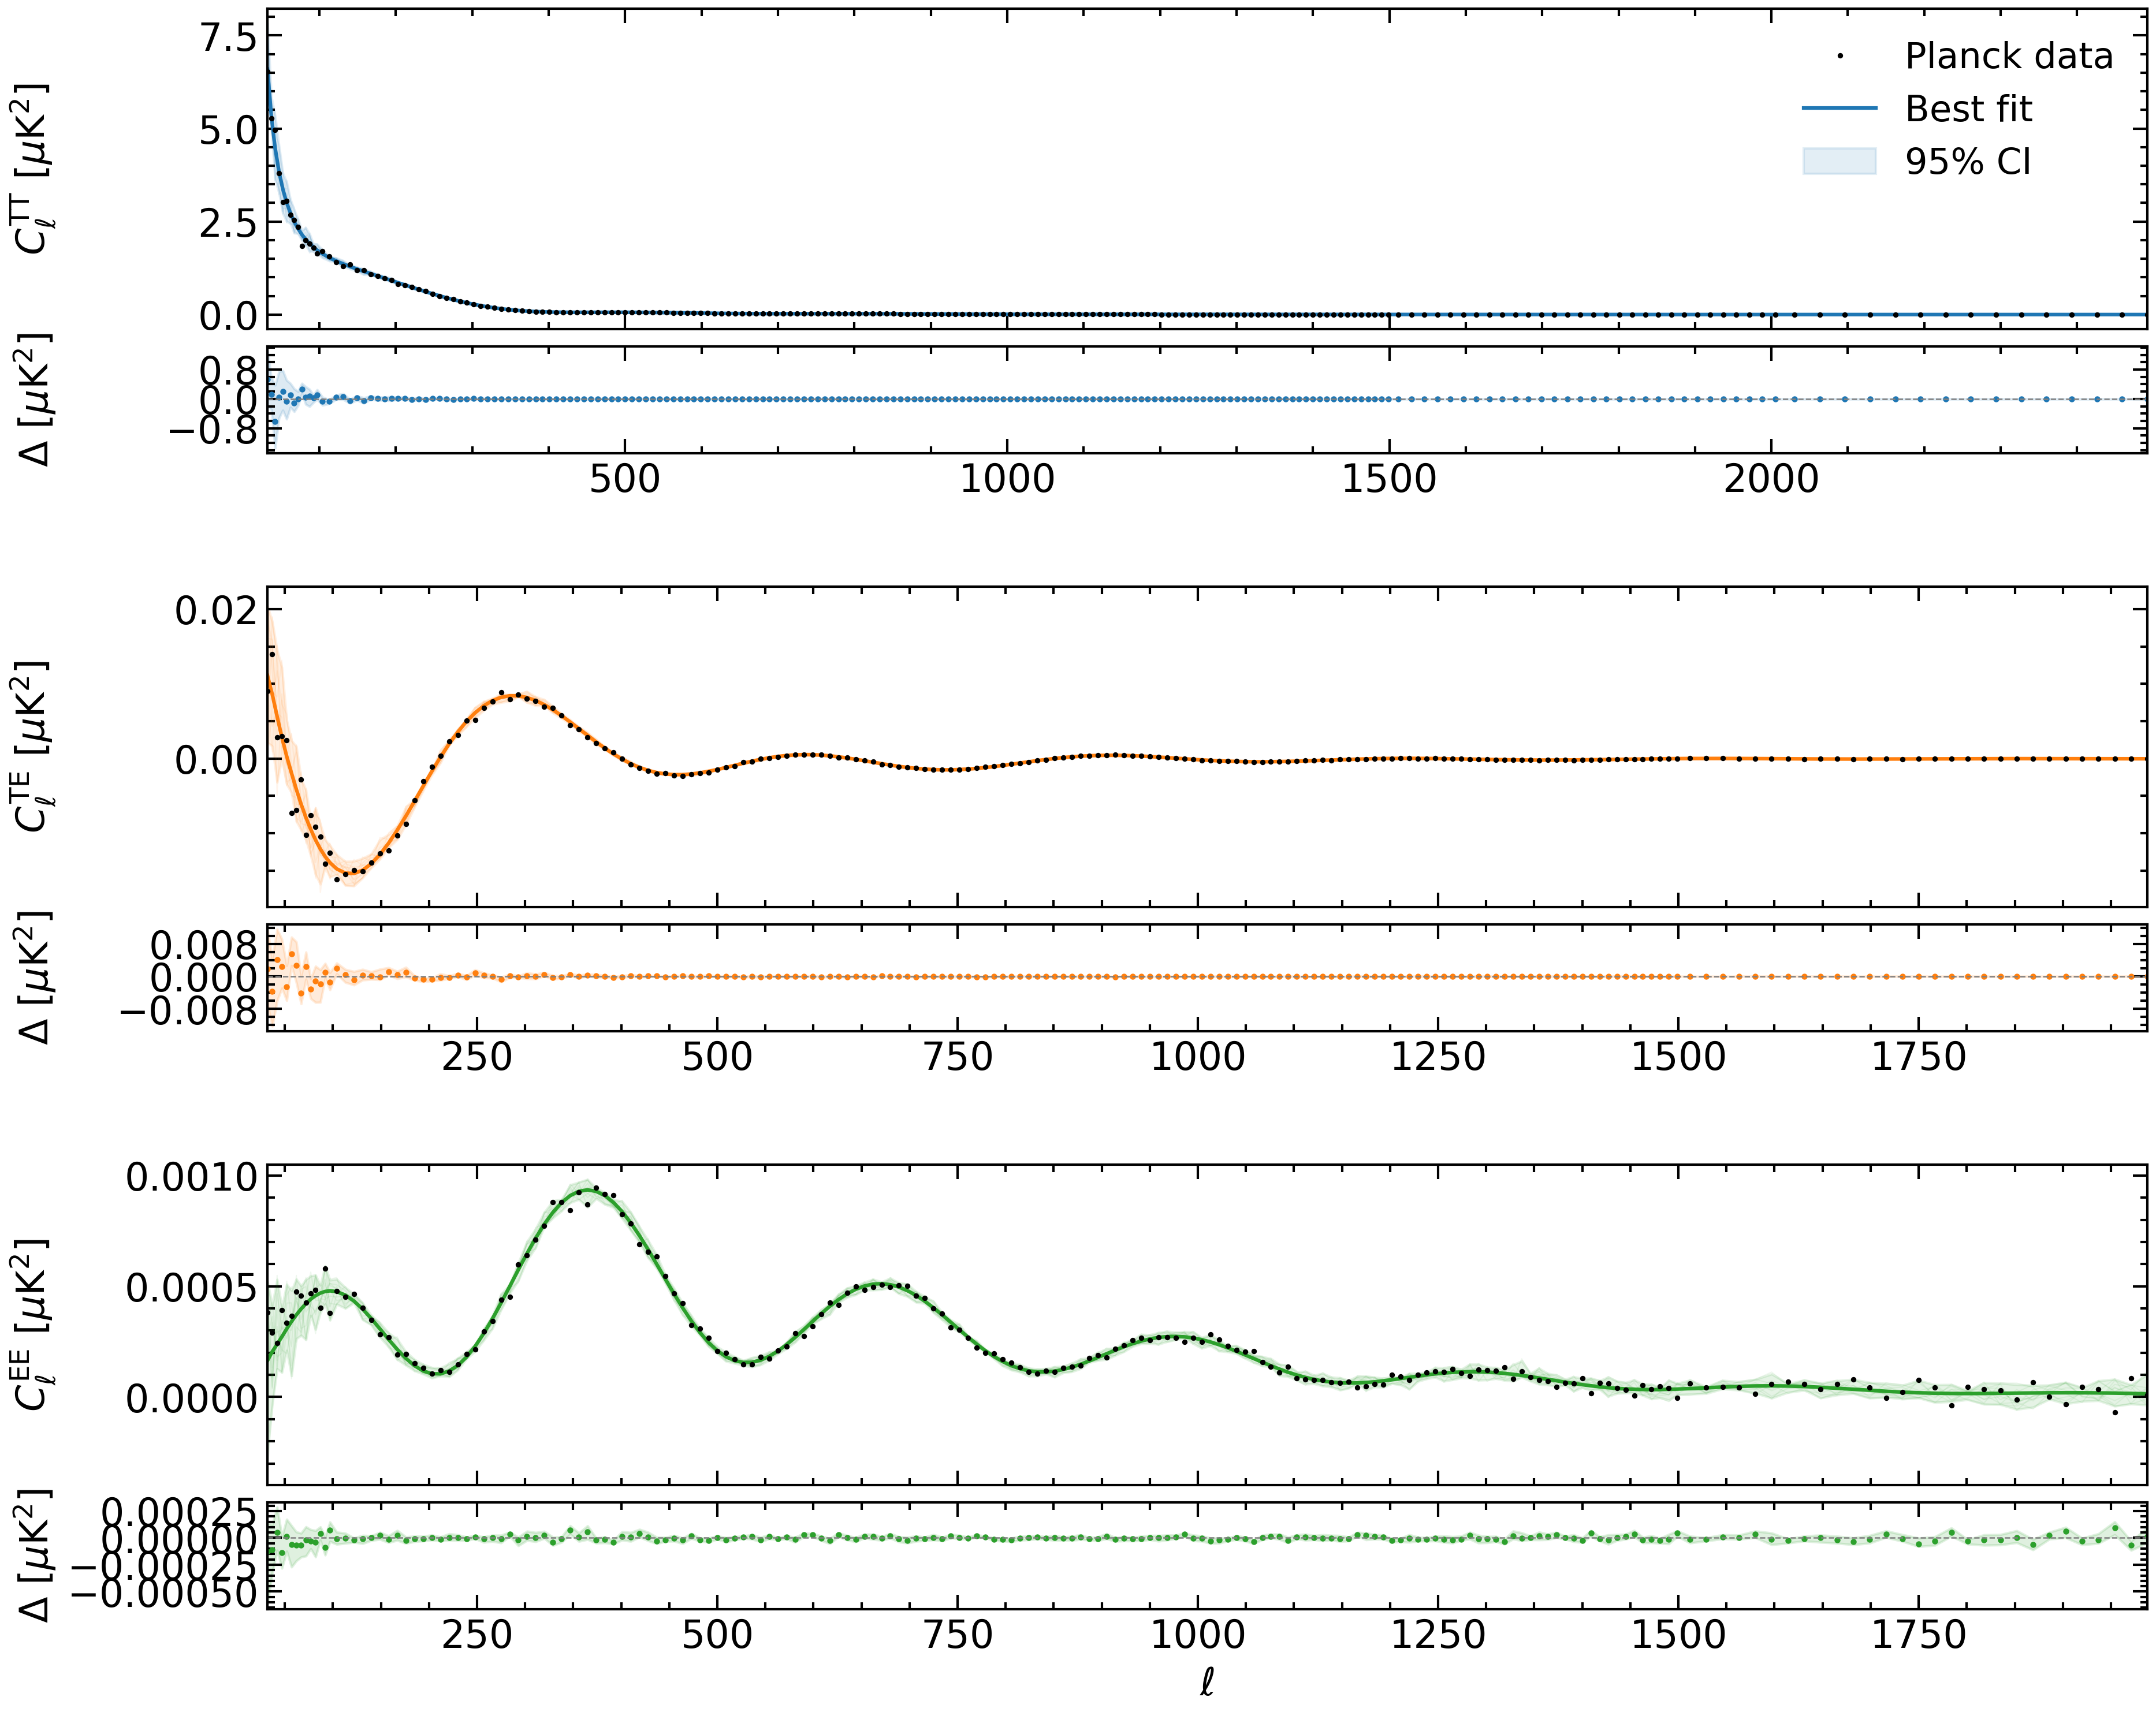

In [10]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib import ticker
from math import pi

plt.style.use(['science', 'notebook'])
colors = {'tt': '#1f77b4', 'te': '#ff7f0e', 'ee': '#2ca02c'}
cl_labels = {'tt': 'TT', 'te': 'TE', 'ee': 'EE'}

fig = plt.figure(figsize=(14, 12))
outer_gs = GridSpec(3, 1, height_ratios=[1, 1, 1], hspace=0.3)
idx = 0
for row_idx, cl in enumerate(['tt', 'te', 'ee']):
    inner_gs = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[row_idx], height_ratios=[3, 1], hspace=0.08)
    n = len(sim.bin_indices[cl])
    ell = ell_centres[cl]
    c_cl = clean_by_cl[cl]
    d_cl = sim.X_data[idx:idx+n]
    s_cl = np.array(sims_noisy[cl])

    ci_lo = np.percentile(s_cl, 2.5, axis=0)
    ci_hi = np.percentile(s_cl, 97.5, axis=0)
    resid_lo = ci_lo - d_cl
    resid_hi = ci_hi - d_cl
    resid_mean = np.mean(s_cl, axis=0) - d_cl
    idx += n

    ax1 = fig.add_subplot(inner_gs[0])
    for i in range(n_real):
        ax1.plot(ell, s_cl[i], color=colors[cl], alpha=0.08, lw=0.5)
    ax1.plot(ell, d_cl, 'k.', ms=2.5, label='Planck data', zorder=10)
    ax1.plot(ell, c_cl, '-', color=colors[cl], lw=1.5, label=f'Best fit')
    ax1.fill_between(ell, ci_lo, ci_hi, alpha=0.12, color=colors[cl], label='95% CI')
    ylab = rf'$C_\ell^{{\mathrm{{{cl.upper()}}}}}$ [$\mu$K$^2$]'
    ax1.set_ylabel(ylab)
    if row_idx == 0:
        ax1.legend(fontsize=15, loc='upper right')
    ax1.tick_params(labelbottom=False)
    ax1.set_xlim(ell[0], ell[-1])

    ax2 = fig.add_subplot(inner_gs[1], sharex=ax1)
    ax2.plot(ell, resid_mean, '.', color=colors[cl], ms=3)
    ax2.fill_between(ell, resid_lo, resid_hi, alpha=0.15, color=colors[cl])
    ax2.axhline(0, color='gray', ls='--', lw=0.6)
    ax2.set_ylabel(r'$\Delta$ [$\mu$K$^2$]')
    ax2.set_xlim(ell[0], ell[-1])
    ax2.yaxis.set_major_locator(ticker.MaxNLocator(4))
    for spine in ax2.spines.values():
        spine.set_linewidth(1.0)
    ax2.tick_params(labelbottom=True)
    if row_idx == 2:
        ax2.set_xlabel(r'$\ell$')

fig.align_ylabels()
plt.tight_layout()
# plt.savefig("best_fit_plot_cl.pdf")
plt.show()



/tmp/ipykernel_35659/317980872.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


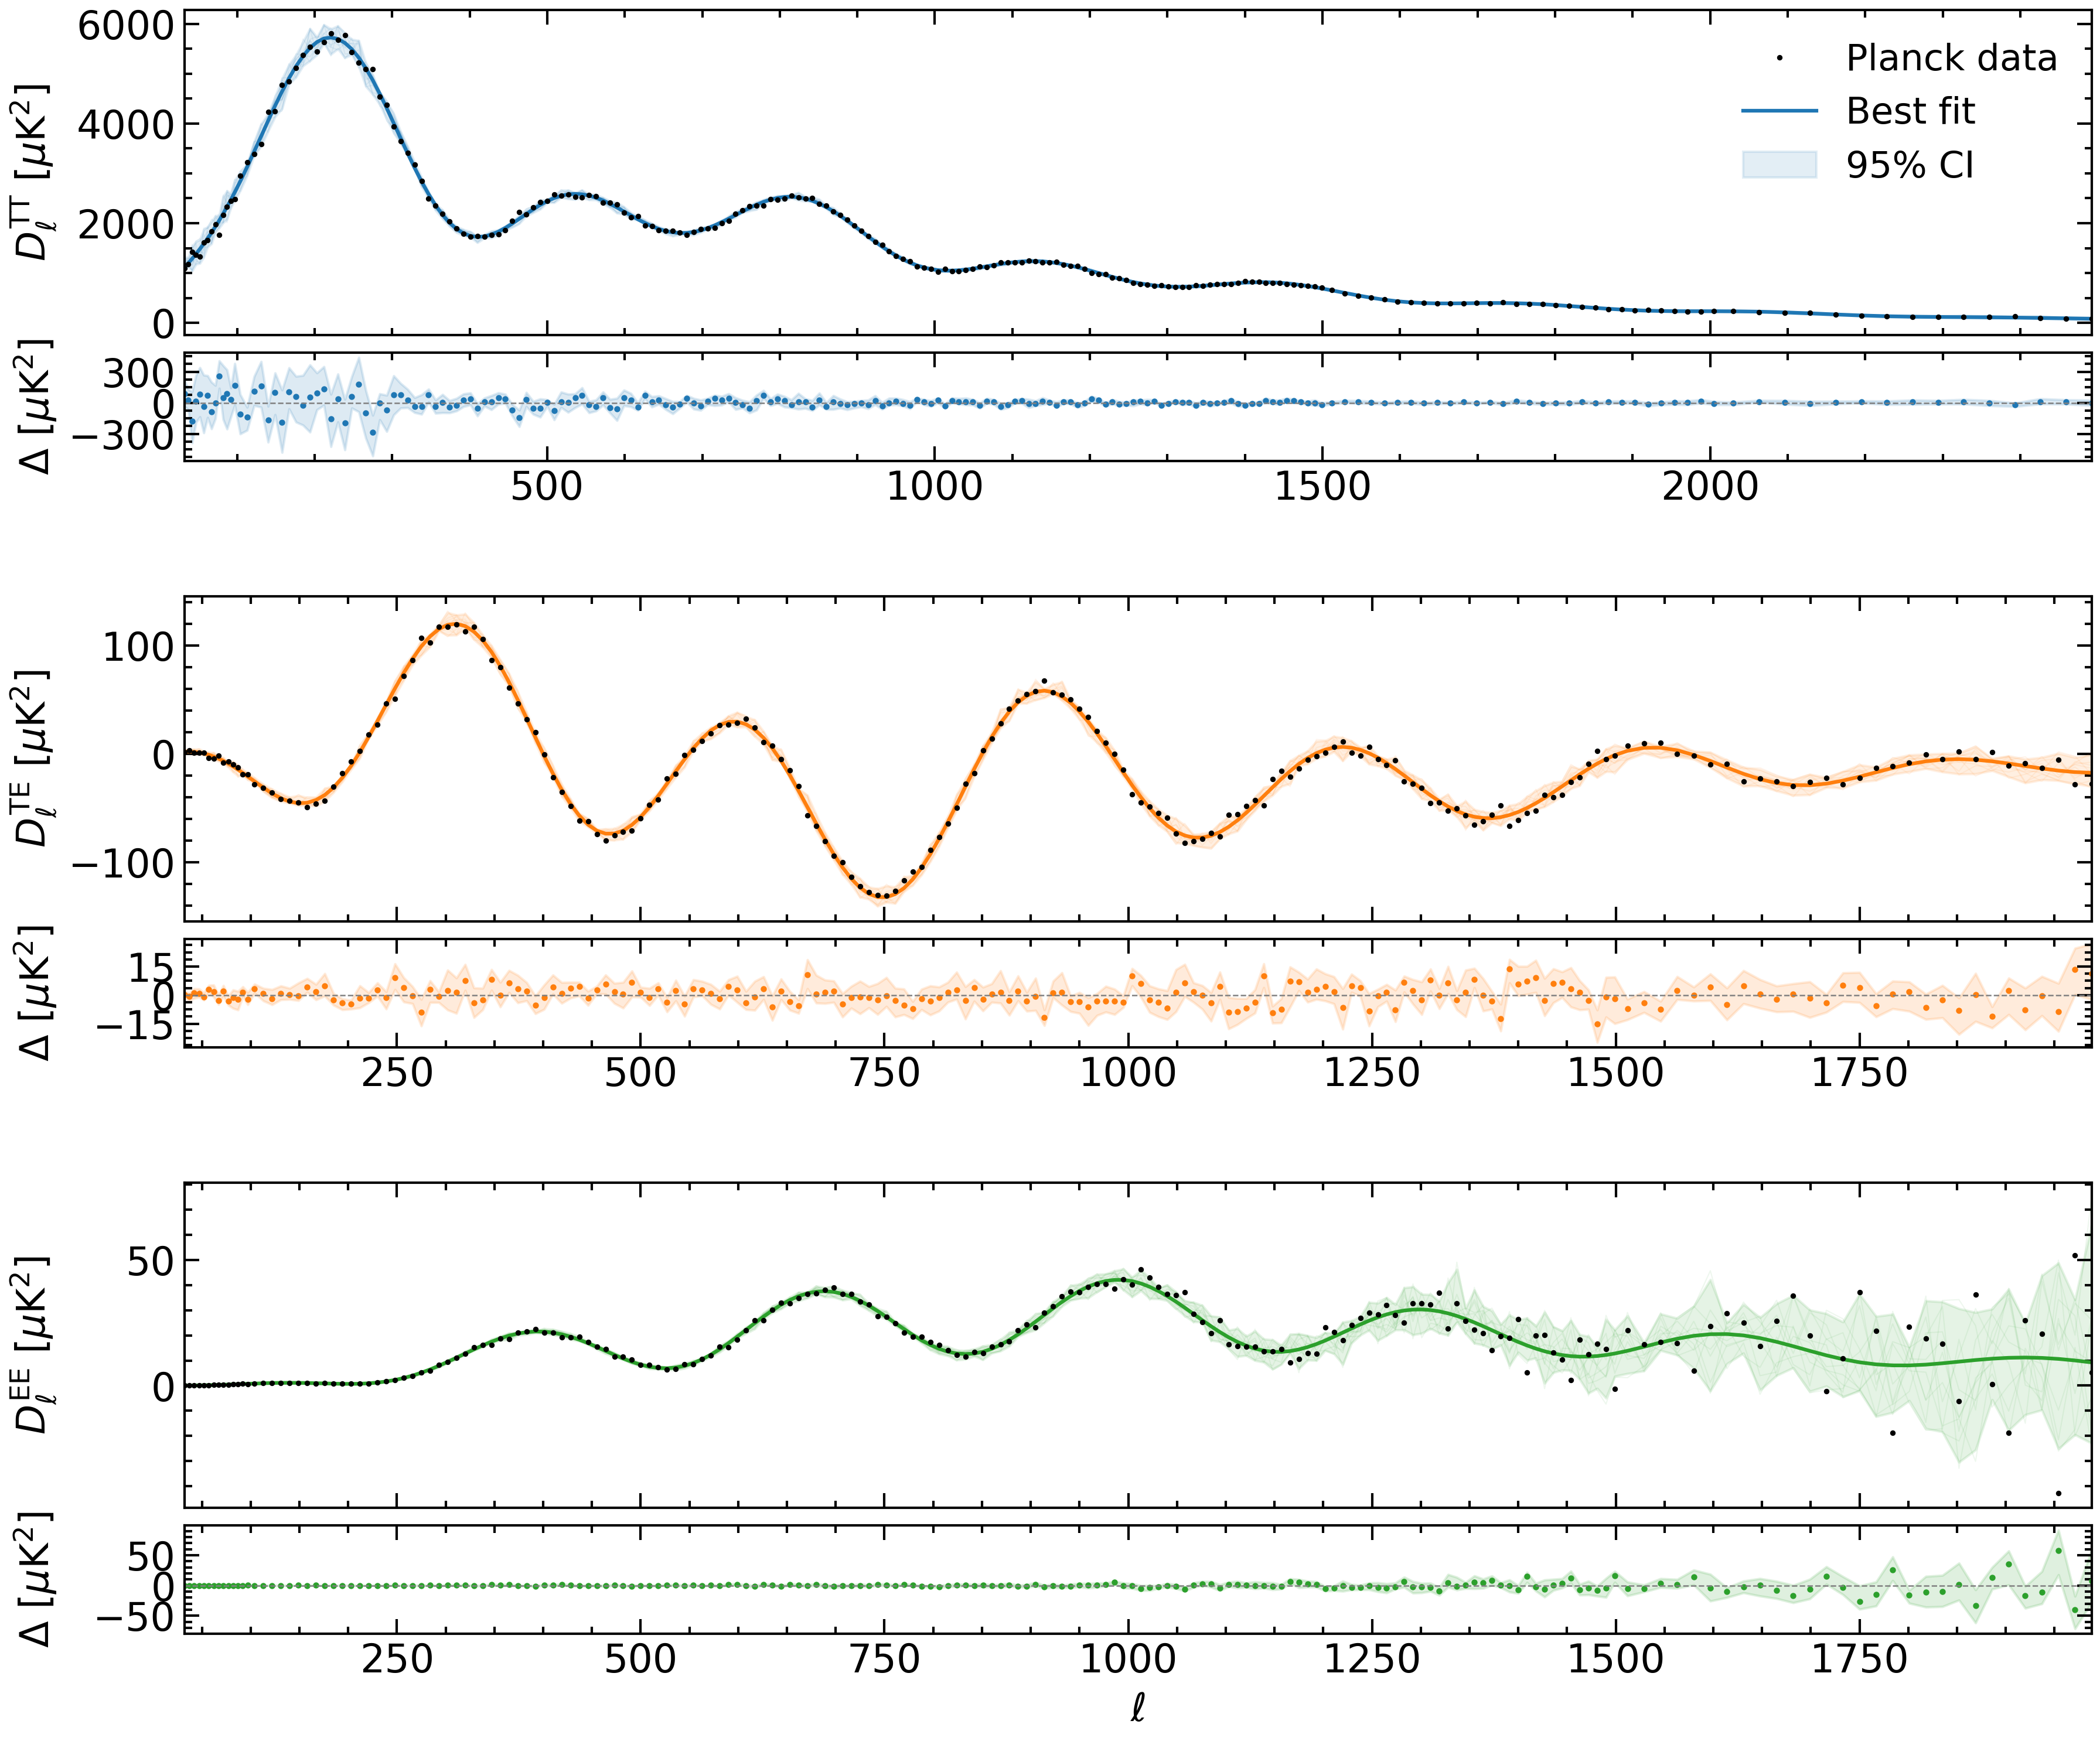

In [11]:
fig = plt.figure(figsize=(14, 12))
outer_gs = GridSpec(3, 1, height_ratios=[1, 1, 1], hspace=0.3)
idx = 0
for row_idx, cl in enumerate(['tt', 'te', 'ee']):
    inner_gs = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[row_idx], height_ratios=[3, 1], hspace=0.08)
    n = len(sim.bin_indices[cl])
    ell = ell_centres[cl]
    fac = ell * (ell + 1) / (2 * pi)
    c_cl = clean_by_cl[cl] * fac
    d_cl = sim.X_data[idx:idx+n] * fac
    s_cl = np.array(sims_noisy[cl]) * fac

    ci_lo = np.percentile(s_cl, 2.5, axis=0)
    ci_hi = np.percentile(s_cl, 97.5, axis=0)
    resid_lo = ci_lo - d_cl
    resid_hi = ci_hi - d_cl
    resid_mean = np.mean(s_cl, axis=0) - d_cl
    idx += n

    ax1 = fig.add_subplot(inner_gs[0])
    for i in range(n_real):
        ax1.plot(ell, s_cl[i], color=colors[cl], alpha=0.08, lw=0.5)
    ax1.plot(ell, d_cl, 'k.', ms=2.5, label='Planck data', zorder=10)
    ax1.plot(ell, c_cl, '-', color=colors[cl], lw=1.5, label=f'Best fit')
    ax1.fill_between(ell, ci_lo, ci_hi, alpha=0.12, color=colors[cl], label='95% CI')
    ylab = rf'$D_\ell^{{\mathrm{{{cl.upper()}}}}}$ [$\mu$K$^2$]'
    ax1.set_ylabel(ylab)
    if row_idx == 0:
        ax1.legend(fontsize=15, loc='upper right')
    ax1.tick_params(labelbottom=False)
    ax1.set_xlim(ell[0], ell[-1])

    ax2 = fig.add_subplot(inner_gs[1], sharex=ax1)
    ax2.plot(ell, resid_mean, '.', color=colors[cl], ms=3)
    ax2.fill_between(ell, resid_lo, resid_hi, alpha=0.15, color=colors[cl])
    ax2.axhline(0, color='gray', ls='--', lw=0.6)
    ax2.set_ylabel(r'$\Delta$ [$\mu$K$^2$]')
    ax2.set_xlim(ell[0], ell[-1])
    ax2.yaxis.set_major_locator(ticker.MaxNLocator(4))
    for spine in ax2.spines.values():
        spine.set_linewidth(1.0)
    ax2.tick_params(labelbottom=True)
    if row_idx == 2:
        ax2.set_xlabel(r'$\ell$')

fig.align_ylabels()
plt.tight_layout()
# plt.savefig("best_fit_plot_dl.pdf")
plt.show()
